In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
from  fastai.vision.all import * 

In [2]:
path = untar_data(URLs.PETS)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:48&lt;00:00]</div>

The dataset can be downloaded and decompressed with this line of code

In [3]:
path.ls()

[Path('/root/.fastai/data/oxford-iiit-pet/images'), Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

above code will only do this download once, and return the location of the decompressed archive. We can check what is inside with the .ls() method.

In [4]:
files = get_image_files(path/"images")
len(files)

7390

 get_image_files is a fastai function that helps us grab all the image files (recursively) in one folder.

In [5]:
files[0],files[6]

(Path('/root/.fastai/data/oxford-iiit-pet/images/beagle_115.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/boxer_128.jpg'))

we can then define an easy label function

In [6]:
def label_func(f) : return f[0].isupper()

To get our data ready for a model, we need to put it in a DataLoaders object

Here we have a function that labels using the file names, so we will use ImageDataLoaders.from_name_func

In [7]:
dls = ImageDataLoaders.from_name_func(path,files,label_func,item_tfms=Resize(224))

item_tfms = transform applied to all images fro resizing
show_batch() method used to check visually 

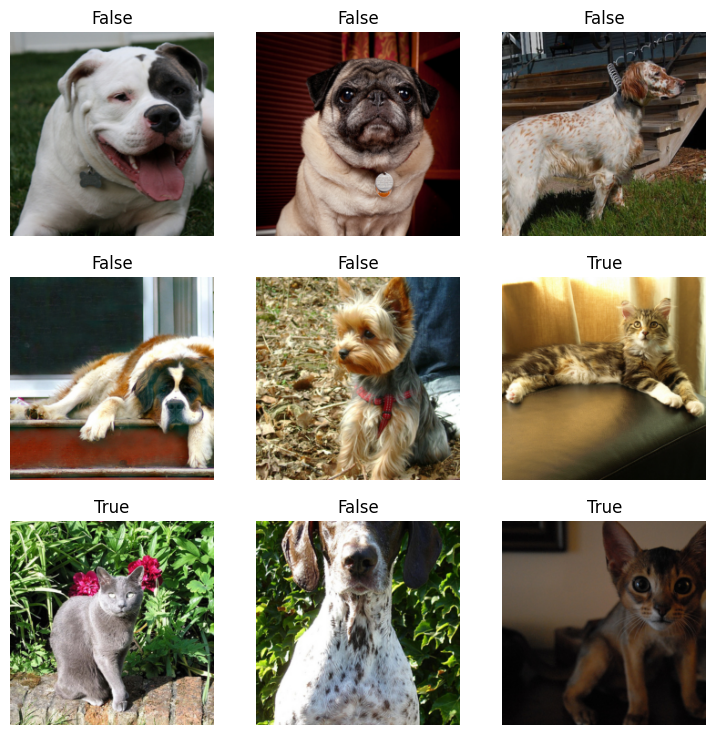

In [8]:
dls.show_batch()


Then we can create a Learner, which is a fastai object that combines the data and a model for training, and uses transfer learning to fine tune a pretrained model in just two lines of code

In [15]:
learn = vision_learner(dls,resnet34,metrics=error_rate)
learn.fine_tune(1)

AttributeError: Exception occured in `ProgressCallback` when calling event `before_fit`:
	'NBMasterBar' object has no attribute 'out'

The first line downloaded a model called ResNet34, pretrained on ImageNet, and adapted it to our specific problem. It then fine tuned that model and in a relatively short time, we get a model with an error rate of well under 1%… amazing

In [16]:
learn.predict(files[0])

epoch,train_loss,valid_loss,error_rate,time


('True', tensor(1), tensor([0.0037, 0.9963]))

The predict method returns three things: the decoded prediction (here False for dog), the index of the predicted class and the tensor of probabilities of all classes in the order of their indexed labels(in this case, the model is quite confident about the being that of a dog)

This method accepts a filename, a PIL image or a tensor directly in this case. We can also have a look at some predictions with the show_results method:

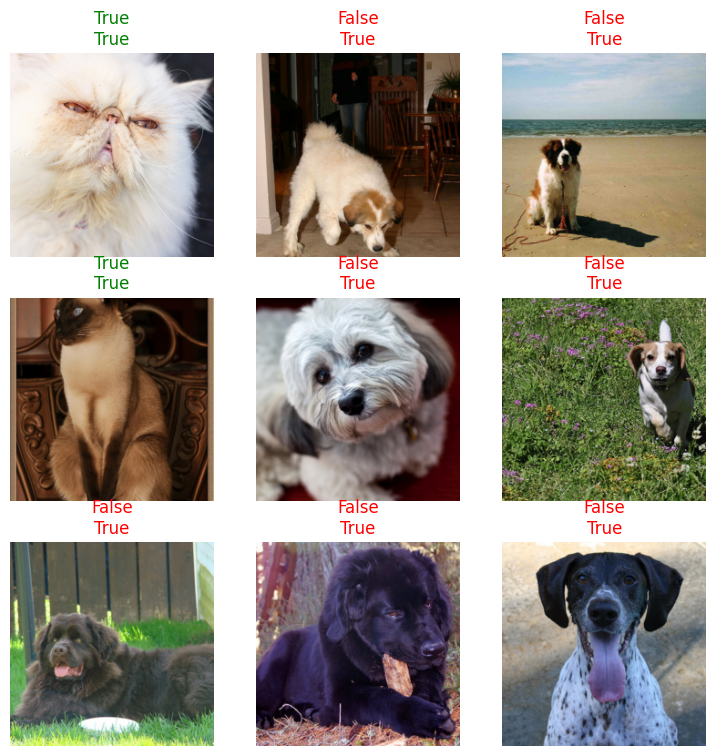

In [18]:
learn.show_results()

In [19]:
files[0]

Path('/root/.fastai/data/oxford-iiit-pet/images/beagle_115.jpg')

In [20]:
files[233]

Path('/root/.fastai/data/oxford-iiit-pet/images/chihuahua_44.jpg')

In [21]:
learn.predict(files[2])

('True', tensor(1), tensor([9.4504e-06, 9.9999e-01]))

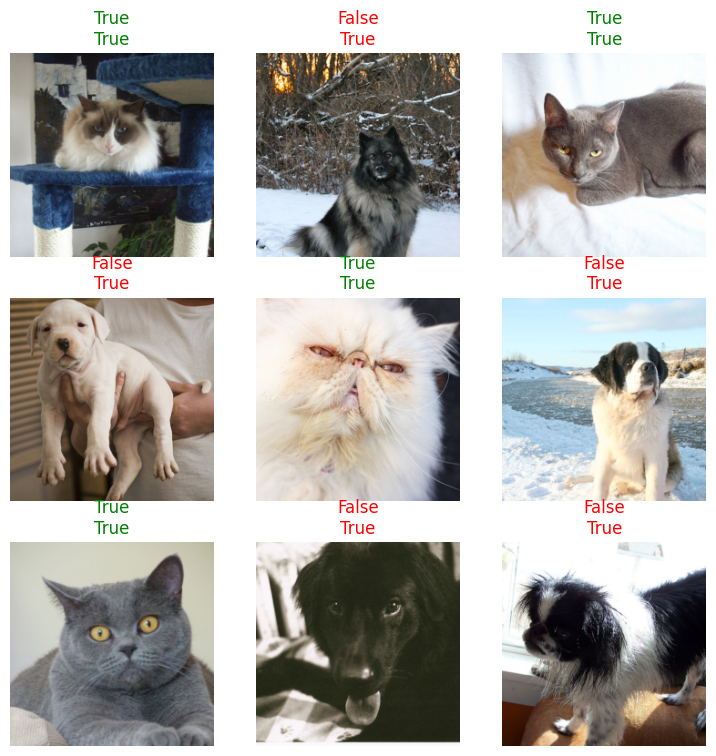

In [22]:
learn.show_results()